In [1]:
%cd ..
import numpy as np
from src.monte_carlo.asianoption import AsianOption
from src.monte_carlo.vanillaoption import VanillaOption
from src.monte_carlo.mcpricer import MCPricer
import matplotlib
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

matplotlib.rcParams.update({
   'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})

/Users/filipporonzino/Desktop/thesis/bsc-thesis/bsc-thesis


In [2]:
# Option parameters
S0 = 100        # Initial stock price
K = 100         # Strike price
T = 1           # Time to maturity (in years)
r = 0.05        # Risk-free rate
sigma = 0.2     # Volatility
n_steps = 252   # Number of time steps
n_sims = 10000  # Number of Monte Carlo simulations

# Create an arithmetic Asian option with pricer
asian_option = AsianOption(S0, K, T, r, sigma, n_steps, 'arithmetic')
pricer = MCPricer(n_sims, n_steps)

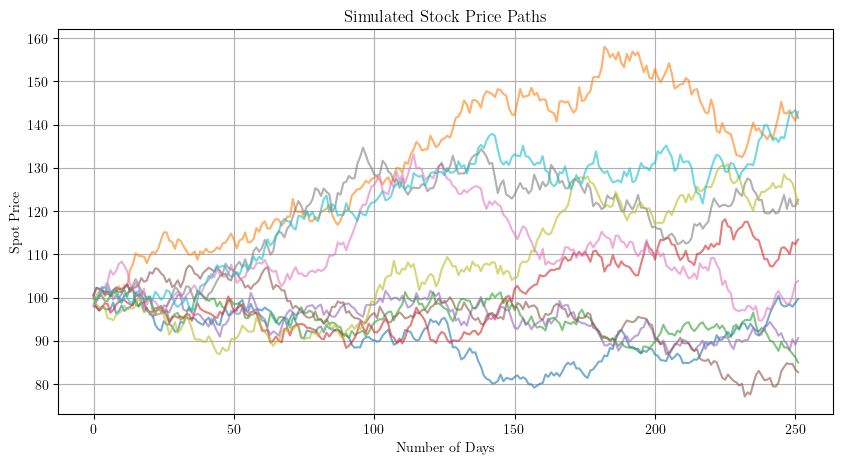

In [3]:
# Generate paths
paths = pricer.generate_paths(asian_option)

# Plot a subset of the simulated paths
plt.figure(figsize=(10, 5))
for i in range(10):  # Plot 10 sample paths
    plt.plot(range(n_steps), paths[i], alpha=0.6)

plt.xlabel("Number of Days")
plt.ylabel("Spot Price")
plt.title("Simulated Stock Price Paths")
plt.grid(True)
plt.show()


In [6]:
from scipy.stats import ttest_rel

# Generate payoffs for both methods
payoffs_simple = pricer.calculate_payoffs(asian_option, use_control_variate=False)
payoffs_cv = pricer.calculate_payoffs(asian_option, use_control_variate=True)

# Print standard errors
print(f"Standard error without control variate: {pricer.std_error(asian_option, use_control_variate=False):.4f}")
print(f"Standard error with control variate: {pricer.std_error(asian_option, use_control_variate=True):.4f}")

# Perform a paired t-test on the variance reduction
t_stat, p_value = ttest_rel(payoffs_simple, payoffs_cv, alternative='greater')

# Print results
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("The variance reduction using control variate is statistically significant.")
else:
    print("No significant variance reduction detected.")


Standard error without control variate: 0.0817
Standard error with control variate: 0.0022
T-statistic: 4.2116
P-value: 0.0000
The variance reduction using control variate is statistically significant.


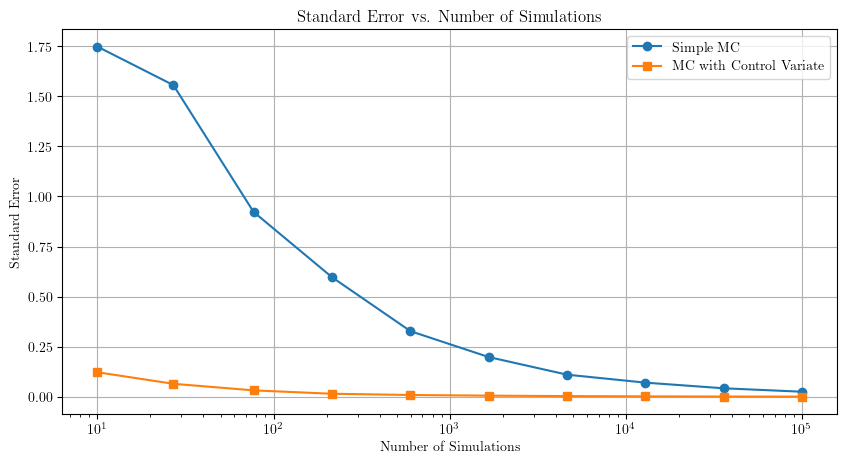

In [12]:
n_sims_list = np.logspace(1, 5, 10, dtype=int)
std_errors_simple = []
std_errors_cv = []

for sims in n_sims_list:
    pricer = MCPricer(sims, n_steps)
    
    std_errors_simple.append(pricer.std_error(asian_option, use_control_variate=False))
    std_errors_cv.append(pricer.std_error(asian_option, use_control_variate=True))

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(n_sims_list, std_errors_simple, label="Simple MC", marker="o")
plt.plot(n_sims_list, std_errors_cv, label="MC with Control Variate", marker="s")

plt.xscale("log")
plt.xlabel("Number of Simulations")
plt.ylabel("Standard Error")
plt.title("Standard Error vs. Number of Simulations")
plt.legend()
plt.grid(True)
plt.show()
